In [ ]:
import pandas as pd

In [ ]:
import numpy as np

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import seaborn as sns

In [ ]:
import glob

In [ ]:
sns.set(style="whitegrid")

In [ ]:
features = pd.read_csv(r'C:\Users\User\Downloads\NUSW-NB15_features\NUSW-NB15_features.csv', encoding='latin1')

In [ ]:
features

,No.,Name,Type,Description
0,1,srcip,nominal,Source IP address
1,2,sport,integer,Source port number
2,3,dstip,nominal,Destination IP address
3,4,dsport,integer,Destination port number
4,5,proto,nominal,Transaction protocol
5,6,state,nominal,Indicates to the state and its dependent proto...
6,7,dur,Float,Record total duration
7,8,sbytes,Integer,Source to destination transaction bytes
8,9,dbytes,Integer,Destination to source transaction bytes
9,10,sttl,Integer,Source to destination time to live value


In [ ]:
col_names = features['Name'].apply(lambda x: x.strip().lower()).tolist()

In [ ]:
print("Colonnes récupérées :", col_names)

Colonnes récupérées : ['srcip', 'sport', 'dstip', 'dsport', 'proto', 'state', 'dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'service', 'sload', 'dload', 'spkts', 'dpkts', 'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz', 'dmeansz', 'trans_depth', 'res_bdy_len', 'sjit', 'djit', 'stime', 'ltime', 'sintpkt', 'dintpkt', 'tcprtt', 'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl', 'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'attack_cat', 'label']


In [ ]:
df1 = pd.read_csv(r'C:\Users\User\Downloads\NUSW-NB15_features\UNSW-NB15_1.csv', names=col_names, header=None, low_memory=False)

In [ ]:
df2 = pd.read_csv(r'C:\Users\User\Downloads\NUSW-NB15_features\UNSW-NB15_2.csv', names=col_names, header=None, low_memory=False)

In [ ]:
df3 = pd.read_csv(r'C:\Users\User\Downloads\NUSW-NB15_features\UNSW-NB15_3.csv', names=col_names, header=None, low_memory=False)

In [ ]:
df4 = pd.read_csv(r'C:\Users\User\Downloads\NUSW-NB15_features\UNSW-NB15_4.csv', names=col_names, header=None, low_memory=False)

In [ ]:
df = pd.concat([df1, df2, df3, df4], ignore_index=True)

In [ ]:
print(f"Taille du dataset fusionné : {df.shape}")

Taille du dataset fusionné : (2540047, 49)


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2540047 entries, 0 to 2540046
Data columns (total 49 columns):
 #   Column            Dtype  
---  ------            -----  
 0   srcip             object 
 1   sport             object 
 2   dstip             object 
 3   dsport            object 
 4   proto             object 
 5   state             object 
 6   dur               float64
 7   sbytes            int64  
 8   dbytes            int64  
 9   sttl              int64  
 10  dttl              int64  
 11  sloss             int64  
 12  dloss             int64  
 13  service           object 
 14  sload             float64
 15  dload             float64
 16  spkts             int64  
 17  dpkts             int64  
 18  swin              int64  
 19  dwin              int64  
 20  stcpb             int64  
 21  dtcpb             int64  
 22  smeansz           int64  
 23  dmeansz           int64  
 24  trans_depth       int64  
 25  res_bdy_len       int64  
 26  sjit          

In [ ]:
print("\nValeurs manquantes (NaN) par colonne :")
print(df.isnull().sum()[df.isnull().sum() > 0])


Valeurs manquantes (NaN) par colonne :
ct_flw_http_mthd    1348145
is_ftp_login        1429879
attack_cat          2218764
dtype: int64


In [ ]:
print("\nNombre de '-' dans la colonne 'service' :", (df['service'] == '-').sum())


Nombre de '-' dans la colonne 'service' : 1246397


In [ ]:
print("\nStatistiques descriptives :")
print(df[['dur', 'sbytes', 'dbytes', 'spkts', 'dpkts']].describe())


Statistiques descriptives :
                dur        sbytes        dbytes         spkts         dpkts
count  2.540047e+06  2.540047e+06  2.540047e+06  2.540047e+06  2.540047e+06
mean   6.587916e-01  4.339600e+03  3.642759e+04  3.328884e+01  4.272664e+01
std    1.392493e+01  5.640599e+04  1.610960e+05  7.628388e+01  1.215020e+02
min    0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00
25%    1.037000e-03  2.000000e+02  1.780000e+02  2.000000e+00  2.000000e+00
50%    1.586100e-02  1.470000e+03  1.820000e+03  1.200000e+01  1.200000e+01
75%    2.145545e-01  3.182000e+03  1.489400e+04  4.400000e+01  4.200000e+01
max    8.786638e+03  1.435577e+07  1.465753e+07  1.064600e+04  1.101800e+04


In [ ]:
print("\nRépartition Binaire (Normal vs Attaque) :")
print(df['label'].value_counts())


Répartition Binaire (Normal vs Attaque) :
label
0    2218764
1     321283
Name: count, dtype: int64


In [ ]:
cols_to_drop = ['srcip', 'sport', 'dstip', 'dsport', 'stime', 'ltime']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

In [ ]:
df['is_ftp_login'] = df['is_ftp_login'].fillna(0)

In [ ]:
df['ct_flw_http_mthd'] = df['ct_flw_http_mthd'].fillna(0)

In [ ]:
df['attack_cat'] = df['attack_cat'].fillna('Normal').str.strip()

In [ ]:
df.dropna(inplace=True)

In [ ]:
df['service'] = df['service'].replace('-', 'undefined')

In [ ]:
numeric_cols = df.select_dtypes(include=['object']).columns.drop(['proto', 'state', 'service', 'attack_cat'])

In [ ]:
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

In [ ]:
print(f"Nettoyage terminé. Nouvelle taille du dataset : {df.shape}")


Nettoyage terminé. Nouvelle taille du dataset : (2540047, 43)


In [ ]:
print("Vérification des NaN restants :", df.isnull().sum().sum())

Vérification des NaN restants : 0


In [ ]:
df['attack_cat'] = df['attack_cat'].fillna('Normal').str.strip()

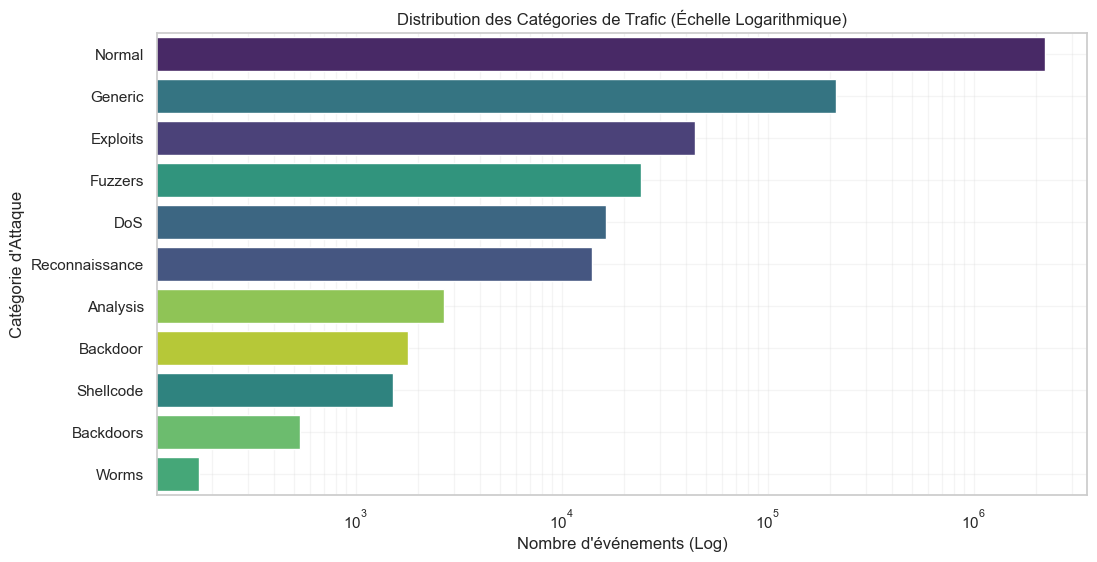

In [ ]:
plt.figure(figsize=(12, 6))
attack_order = df['attack_cat'].value_counts().index
sns.countplot(data=df, y='attack_cat', order=attack_order, hue='attack_cat', palette='viridis', legend=False)
plt.xscale('log')
plt.title('Distribution des Catégories de Trafic (Échelle Logarithmique)')
plt.xlabel('Nombre d\'événements (Log)')
plt.ylabel('Catégorie d\'Attaque')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

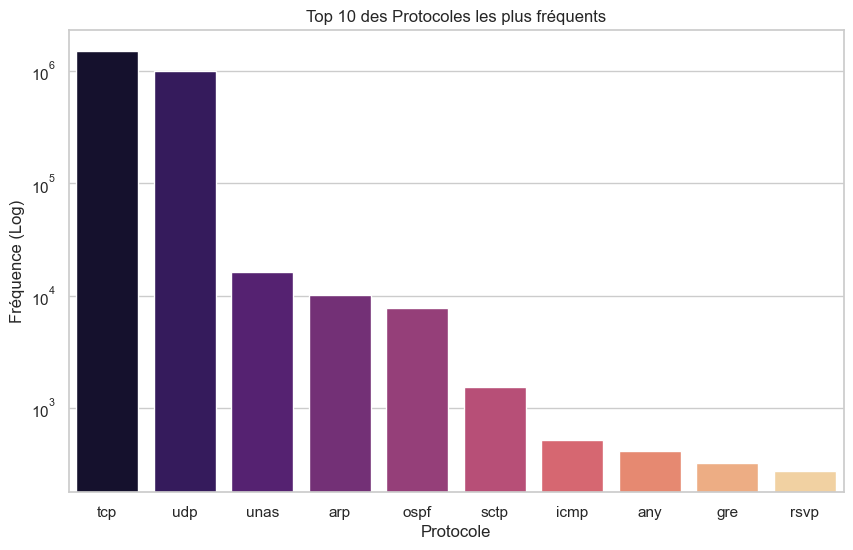

In [ ]:
plt.figure(figsize=(10, 6))
top_proto = df['proto'].value_counts().head(10)
sns.barplot(x=top_proto.index, y=top_proto.values, hue=top_proto.index, palette='magma', legend=False)

plt.yscale('log')
plt.title('Top 10 des Protocoles les plus fréquents')
plt.ylabel('Fréquence (Log)')
plt.xlabel('Protocole')
plt.show()

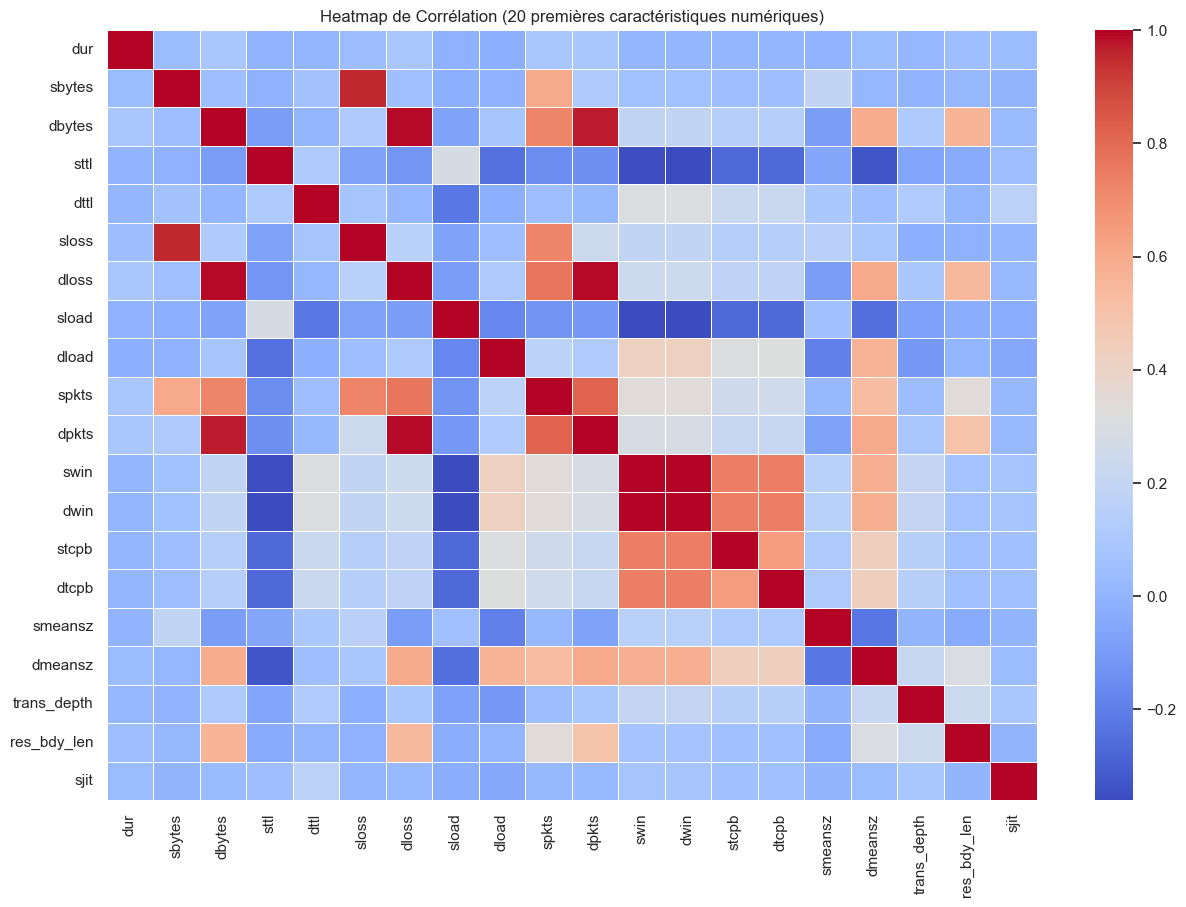

In [ ]:
plt.figure(figsize=(15, 10))
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop(['label'], errors='ignore')
corr_matrix = df[numeric_cols].iloc[:, :20].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap de Corrélation (20 premières caractéristiques numériques)')
plt.show()

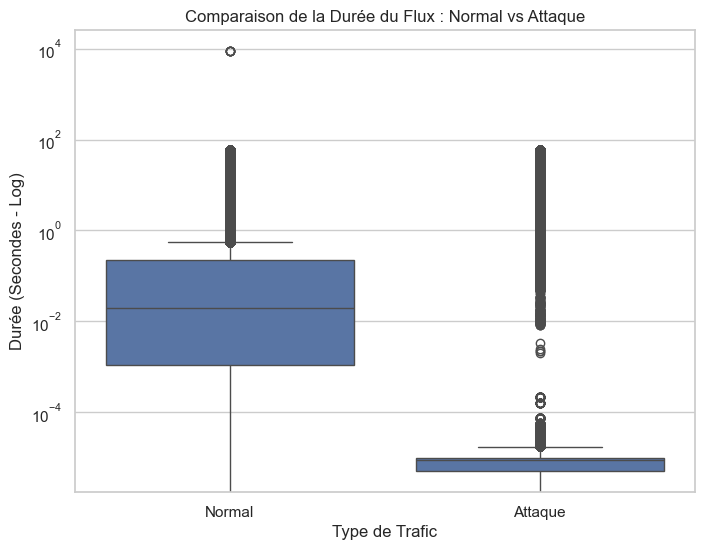

In [ ]:
plt.figure(figsize=(8, 6))
# Création d'un label textuel pour la clarté
df['label_text'] = df['label'].map({0: 'Normal', 1: 'Attaque'})

sns.boxplot(x='label_text', y='dur', data=df)
plt.yscale('log') # Log scale car les durées varient de 0 à des milliers
plt.title('Comparaison de la Durée du Flux : Normal vs Attaque')
plt.ylabel('Durée (Secondes - Log)')
plt.xlabel('Type de Trafic')
plt.show()

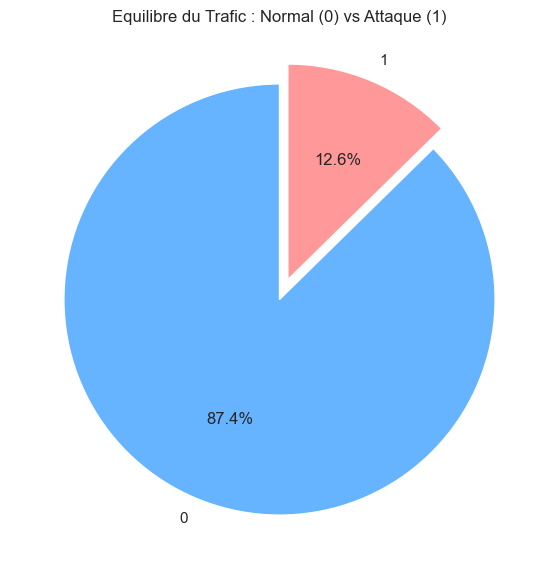

In [ ]:
plt.figure(figsize=(7,7))
df['label'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=90, explode=(0, 0.1))
plt.title('Equilibre du Trafic : Normal (0) vs Attaque (1)')
plt.ylabel('')
plt.show()

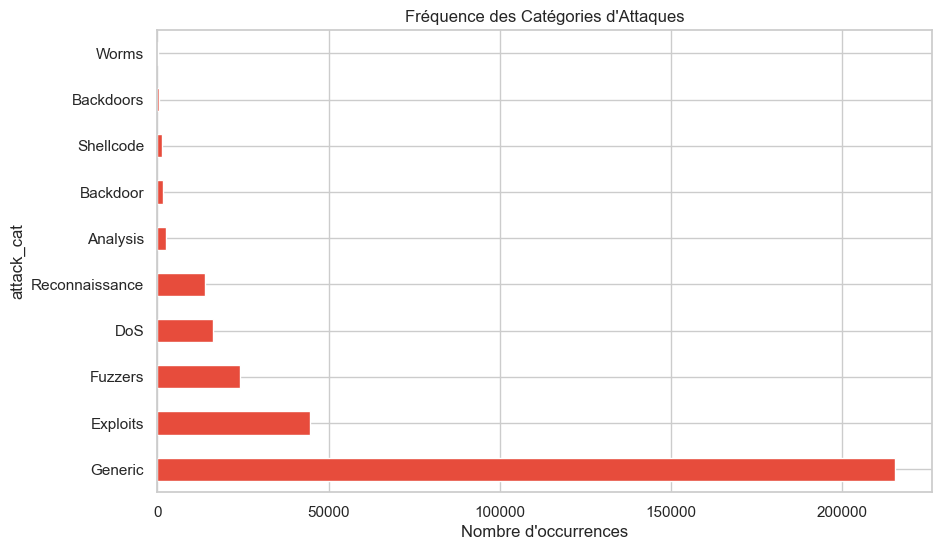

In [ ]:
plt.figure(figsize=(10,6))
df[df['label'] == 1]['attack_cat'].value_counts().plot(kind='barh', color='#e74c3c')
plt.title('Fréquence des Catégories d\'Attaques')
plt.xlabel('Nombre d\'occurrences')
plt.show()

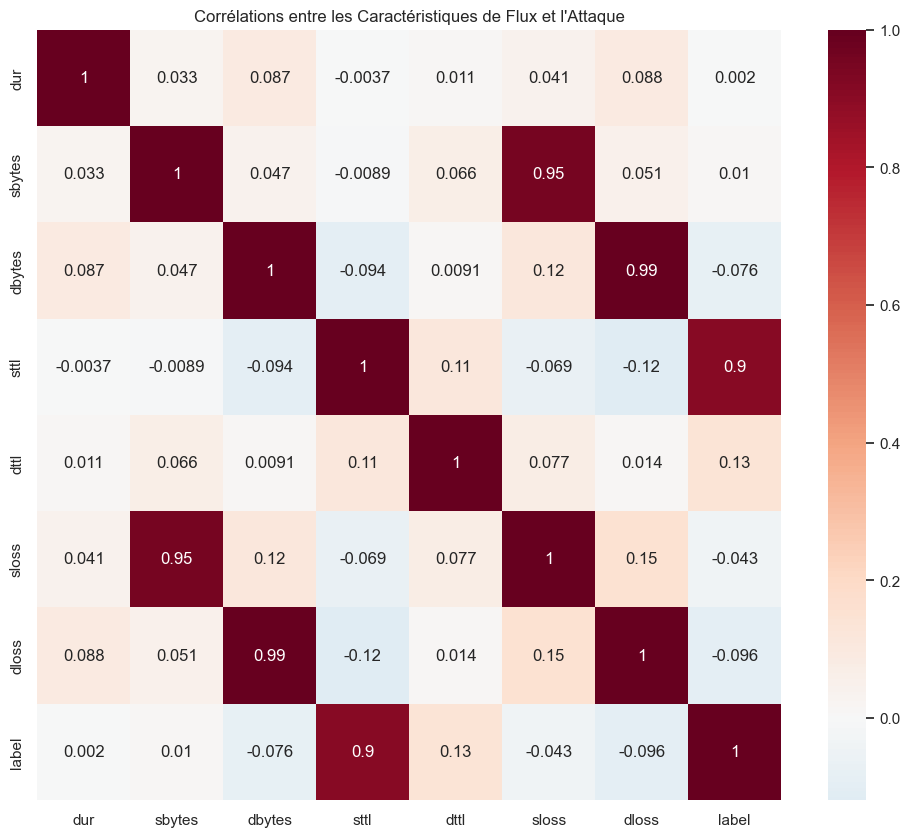

In [ ]:
plt.figure(figsize=(12, 10))
# On choisit les colonnes de flux les plus importantes
flux_cols = ['dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'label']
sns.heatmap(df[flux_cols].corr(), annot=True, cmap='RdBu_r', center=0)
plt.title('Corrélations entre les Caractéristiques de Flux et l\'Attaque')
plt.show()

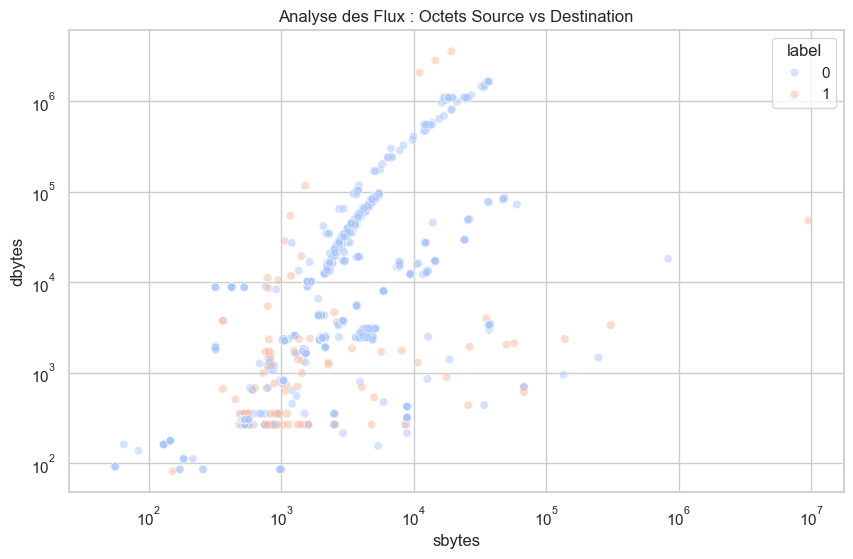

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df.sample(5000), x='sbytes', y='dbytes', hue='label', alpha=0.5, palette='coolwarm')
plt.xscale('log')
plt.yscale('log')
plt.title('Analyse des Flux : Octets Source vs Destination')
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
#Création du Ratio d'octets (Source vs Destination)
df['bytes_ratio'] = df['sbytes'] / (df['dbytes'] + 1)

In [ ]:
# 2. Vitesse de transmission (Paquets par seconde)
df['packet_rate'] = (df['spkts'] + df['dpkts']) / (df['dur'] + 0.0001)

In [ ]:
# 3. Score de perte réseau (Fiabilité du flux)
df['loss_rate'] = (df['sloss'] + df['dloss']) / (df['spkts'] + df['dpkts'] + 1)

In [ ]:
print("Nouvelles caractéristiques créées : bytes_ratio, packet_rate, loss_rate")

Nouvelles caractéristiques créées : bytes_ratio, packet_rate, loss_rate


In [ ]:
print(df[['bytes_ratio', 'packet_rate', 'loss_rate', 'label']].corr()['label'])

bytes_ratio    0.117923
packet_rate    0.042395
loss_rate     -0.309371
label          1.000000
Name: label, dtype: float64


In [ ]:
categorical_cols = ['proto', 'service', 'state']

In [ ]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [ ]:
print(f"Nombre de colonnes après encodage : {df_encoded.shape[1]}")

Nombre de colonnes après encodage : 205


In [ ]:
X = df_encoded.drop(columns=['label', 'attack_cat', 'label_text'], errors='ignore')

In [ ]:
y = df_encoded['label']

In [ ]:
scaler = StandardScaler()

In [ ]:
X_scaled = scaler.fit_transform(X)

In [ ]:
print("Normalisation terminée. Toutes les données sont maintenant à la même échelle.")

Normalisation terminée. Toutes les données sont maintenant à la même échelle.


In [ ]:
categorical_list = df.select_dtypes(include=['object']).columns.tolist()

In [ ]:
print("Colonnes détectées comme étant du texte :")
for col in categorical_list:
    # On affiche le nom et le nombre de catégories uniques
    unique_count = df[col].nunique()
    print(f"- {col} : {unique_count} catégories uniques")

Colonnes détectées comme étant du texte :
- proto : 135 catégories uniques
- state : 16 catégories uniques
- service : 13 catégories uniques
- attack_cat : 11 catégories uniques
- label_text : 2 catégories uniques


In [ ]:
features_to_encode = [c for c in categorical_list if c != 'attack_cat']
print(f"\nConclusion : Nous devons encoder {features_to_encode}")


Conclusion : Nous devons encoder ['proto', 'state', 'service', 'label_text']


In [ ]:
#creation d'un échantillon

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
sample_size = 50000

In [ ]:
if len(df_encoded) > sample_size:
    fraction = sample_size / len(df_encoded)
else:
    # Si le fichier est petit, on prend 90% pour laisser de la place au test
    fraction = 0.9

print(f"Utilisation de train_size = {fraction}")

Utilisation de train_size = 0.019684675126090186


In [ ]:
df_sample, _ = train_test_split(
    df_encoded,
    train_size=fraction,
    stratify=df_encoded['label'],
    random_state=42
)

In [ ]:
X_sample = df_sample.drop(columns=['label', 'attack_cat', 'label_text'], errors='ignore')

In [ ]:
y_sample = df_sample['label']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_sample,
    y_sample,
    test_size=0.2,
    stratify=y_sample,
    random_state=42
)

In [ ]:
scaler = StandardScaler()

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
print(f"Prêt pour l'entraînement ! Taille finale du Train : {X_train_scaled.shape}")

Prêt pour l'entraînement ! Taille finale du Train : (40000, 202)


In [ ]:
#Class Weights

In [ ]:
print("Répartition dans le set d'entraînement :")
print(y_train.value_counts())

Répartition dans le set d'entraînement :
label
0    34941
1     5059
Name: count, dtype: int64


In [ ]:
ratio = y_train.value_counts(normalize=True)
print(f"\nProportions : Normal={ratio[0]:.2%}, Attaque={ratio[1]:.2%}")


Proportions : Normal=87.35%, Attaque=12.65%


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
svm_model = SVC(kernel='linear', class_weight='balanced', C=1.0)

print("\nLe modèle est configuré pour gérer le déséquilibre automatiquement.")


Le modèle est configuré pour gérer le déséquilibre automatiquement.


In [ ]:
#traine the model

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
print("🚀 Entraînement du SVM en cours (cela peut prendre 1 à 2 minutes)...")

🚀 Entraînement du SVM en cours (cela peut prendre 1 à 2 minutes)...


In [ ]:
svm_model = SVC(kernel='linear', class_weight='balanced', random_state=42)

In [ ]:
svm_model.fit(X_train_scaled, y_train)

SVC(class_weight='balanced', kernel='linear', random_state=42)

In [ ]:
y_pred = svm_model.predict(X_test_scaled)

In [ ]:
print("✅ Entraînement terminé !")

✅ Entraînement terminé !


In [ ]:
print("\n📊 RAPPORT DE CLASSIFICATION :")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Attaque']))


📊 RAPPORT DE CLASSIFICATION :
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99      8735
     Attaque       0.92      1.00      0.96      1265

    accuracy                           0.99     10000
   macro avg       0.96      0.99      0.98     10000
weighted avg       0.99      0.99      0.99     10000



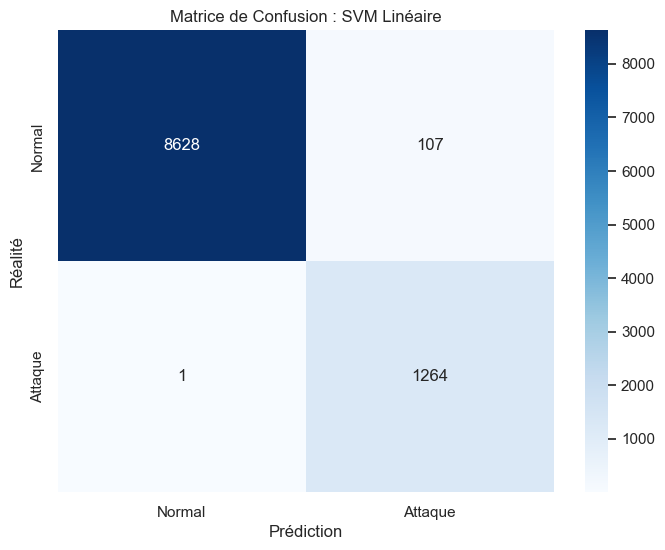

In [ ]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Attaque'], yticklabels=['Normal', 'Attaque'])
plt.title('Matrice de Confusion : SVM Linéaire')
plt.xlabel('Prédiction')
plt.ylabel('Réalité')
plt.show()

In [ ]:
acc = accuracy_score(y_test, y_pred)
print(f"\nPrécision globale (Accuracy) : {acc:.2%}")


Précision globale (Accuracy) : 98.92%


In [ ]:
print("🔄 Lancement du test de robustesse (Suppression du Leakage)...")

🔄 Lancement du test de robustesse (Suppression du Leakage)...


In [ ]:
cols_to_drop = [
    'stime', 'ltime',                             # Temps (Leakage temporel)
    'srcip', 'dstip', 'sport', 'dsport',           # Identifiants (Biais réseau)
    'label', 'attack_cat', 'label_text'            # Cibles et descriptions
]

In [ ]:
X_robust = df_sample.drop(columns=[c for c in cols_to_drop if c in df_sample.columns])
y_robust = df_sample['label']

In [ ]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_robust, y_robust, test_size=0.2, stratify=y_robust, random_state=42
)

In [ ]:
scaler_r = StandardScaler()
X_train_scaled_r = scaler_r.fit_transform(X_train_r)
X_test_scaled_r = scaler_r.transform(X_test_r)

In [ ]:
svm_robust = SVC(kernel='linear', class_weight='balanced', random_state=42)
svm_robust.fit(X_train_scaled_r, y_train_r)

SVC(class_weight='balanced', kernel='linear', random_state=42)

In [ ]:
y_pred_r = svm_robust.predict(X_test_scaled_r)

In [ ]:
print("\n📊 RÉSULTATS DU MODÈLE ROBUSTE (SANS BIAIS) :")
print(classification_report(y_test_r, y_pred_r))


📊 RÉSULTATS DU MODÈLE ROBUSTE (SANS BIAIS) :
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      8735
           1       0.92      1.00      0.96      1265

    accuracy                           0.99     10000
   macro avg       0.96      0.99      0.98     10000
weighted avg       0.99      0.99      0.99     10000



In [ ]:
acc1 = accuracy_score(y_test_r, y_pred_r)
print(f"\nPrécision globale (Accuracy) : {acc1:.2%}")


Précision globale (Accuracy) : 98.92%


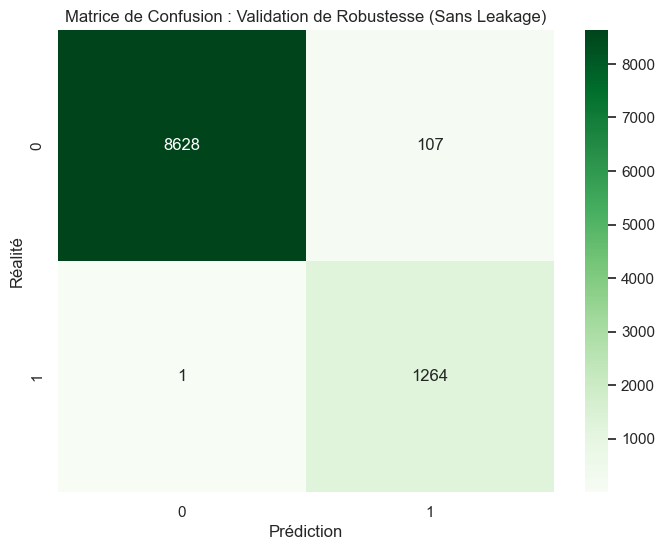

In [ ]:
plt.figure(figsize=(8, 6))
cm_r = confusion_matrix(y_test_r, y_pred_r)
sns.heatmap(cm_r, annot=True, fmt='d', cmap='Greens')
plt.title('Matrice de Confusion : Validation de Robustesse (Sans Leakage)')
plt.xlabel('Prédiction')
plt.ylabel('Réalité')
plt.show()

In [ ]:
from sklearn.decomposition import PCA
import numpy as np
from sklearn.svm import LinearSVC

In [ ]:
print("🚀 Entraînement ultra-rapide avec LinearSVC...")
svm_fast = LinearSVC(class_weight='balanced', random_state=42, dual=False, max_iter=10000)
svm_fast.fit(X_train_scaled_r, y_train_r)
y_pred_fast = svm_fast.predict(X_test_scaled_r)
print("✅ Entraînement terminé !")

🚀 Entraînement ultra-rapide avec LinearSVC...
✅ Entraînement terminé !


In [ ]:
print("🎨 Génération de l'espace PCA...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_test_scaled_r)

🎨 Génération de l'espace PCA...


In [ ]:
h = .05
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

In [ ]:
svc_plot = LinearSVC(class_weight='balanced', dual=False).fit(X_pca, y_test_r)
Z = svc_plot.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

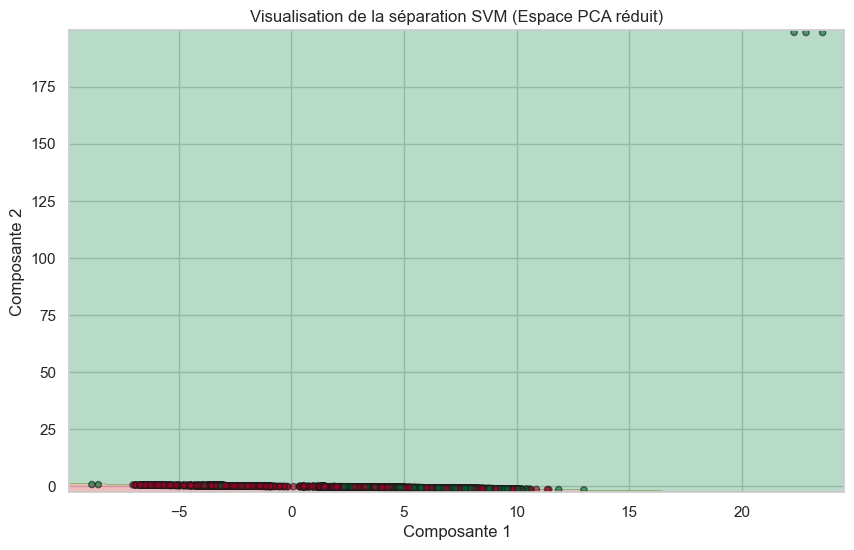

In [ ]:
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, cmap='RdYlGn', alpha=0.3)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_test_r, cmap='RdYlGn', edgecolors='k', s=20, alpha=0.6)
plt.title("Visualisation de la séparation SVM (Espace PCA réduit)")
plt.xlabel("Composante 1")
plt.ylabel("Composante 2")
plt.show()

In [ ]:
coefs = svm_fast.coef_[0]
importance_df = pd.DataFrame({'Variable': X_robust.columns, 'Poids': coefs})
importance_df['Abs_Poids'] = importance_df['Poids'].abs()
importance_df = importance_df.sort_values(by='Abs_Poids', ascending=False).head(10)

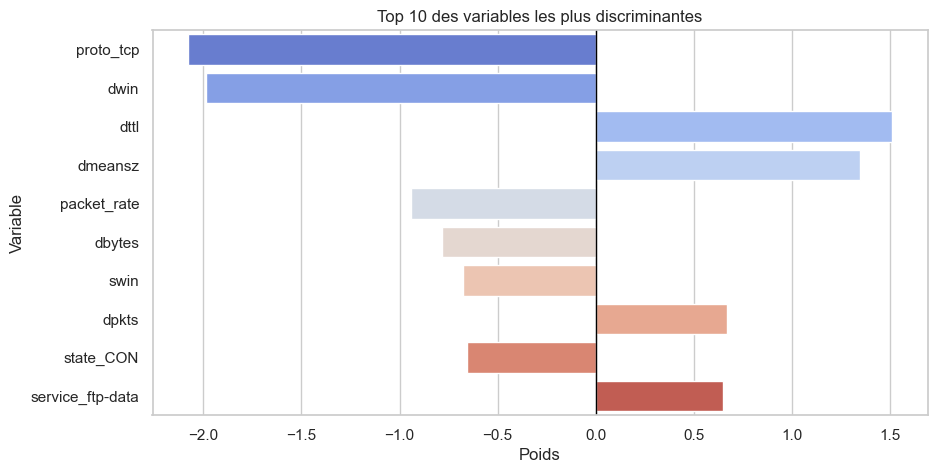

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(x='Poids', y='Variable', data=importance_df, hue='Variable', palette='coolwarm', legend=False)
plt.title("Top 10 des variables les plus discriminantes")
plt.axvline(0, color='black', lw=1)
plt.show()

In [ ]:
test_results = pd.DataFrame({
    'Packet_Rate': X_test_r['packet_rate'].values[:30],
    'Bytes_Ratio': X_test_r['bytes_ratio'].values[:30],
    'Réalité': y_test_r.values[:30],
    'Prédiction': y_pred_fast[:30]
})
print("\n🔍 ANALYSE DES PRÉDICTIONS (Échantillon) :")
display(test_results)


🔍 ANALYSE DES PRÉDICTIONS (Échantillon) :


,Packet_Rate,Bytes_Ratio,Réalité,Prédiction
0,27.191758,0.130966,1,1
1,19417.475728,114.000000,1,1
2,3527.655918,0.126695,0,0
3,149.673675,0.530840,0,0
4,242.340486,0.527320,0,0
5,3561.887801,0.815642,0,0
6,31.807438,0.165601,0,0
7,31.511850,0.165601,0,0
8,1582.352120,0.936170,0,0
9,2581.566517,11.005028,0,0


In [ ]:
y_multi = df_sample['attack_cat']

In [ ]:
class_counts = df_sample['attack_cat'].value_counts()
to_keep = class_counts[class_counts >= 2].index
df_filtered = df_sample[df_sample['attack_cat'].isin(to_keep)]

In [ ]:
print(f"Classes supprimées (trop rares) : {set(class_counts.index) - set(to_keep)}")

Classes supprimées (trop rares) : set()


In [ ]:
y_multi = df_filtered['attack_cat']

In [ ]:
X_multi = X_robust.loc[df_filtered.index]

In [ ]:
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, stratify=y_multi, random_state=42
)

In [ ]:
print("✅ Division réussie après nettoyage des classes orphelines.")

✅ Division réussie après nettoyage des classes orphelines.


In [ ]:
scaler_m = StandardScaler()
X_train_m_scaled = scaler_m.fit_transform(X_train_m)
X_test_m_scaled = scaler_m.transform(X_test_m)

In [ ]:
print("🚀 Entraînement du SVM Multiclasse (Analyse des types d'attaques)...")

🚀 Entraînement du SVM Multiclasse (Analyse des types d'attaques)...


In [ ]:
from sklearn.svm import LinearSVC

# On réduit max_iter et on s'assure que dual=False pour la vitesse
# tol=1e-3 permet de s'arrêter un peu plus tôt sans perdre en précision
svm_multi = LinearSVC(
    class_weight='balanced',
    random_state=42,
    dual=False,
    max_iter=5000,
    tol=1e-2,
    C=0.1
)

print("⚡ Entraînement Multiclasse accéléré...")
svm_multi.fit(X_train_m_scaled, y_train_m)
print("✅ Terminé !")

⚡ Entraînement Multiclasse accéléré...
✅ Terminé !


In [ ]:
y_pred_m = svm_multi.predict(X_test_m_scaled)
print("✅ Analyse terminée !")

✅ Analyse terminée !


In [ ]:
print("\n📊 RAPPORT DÉTAILLÉ PAR TYPE D'ATTAQUE :")
print(classification_report(y_test_m, y_pred_m))


📊 RAPPORT DÉTAILLÉ PAR TYPE D'ATTAQUE :
                precision    recall  f1-score   support

      Analysis       0.19      0.36      0.24        14
      Backdoor       0.08      0.12      0.10         8
     Backdoors       0.07      0.33      0.12         3
           DoS       0.35      0.41      0.38        66
      Exploits       0.69      0.54      0.61       166
       Fuzzers       0.35      0.72      0.47        89
       Generic       1.00      0.98      0.99       853
        Normal       1.00      0.99      0.99      8735
Reconnaissance       0.45      0.42      0.43        60
     Shellcode       0.12      0.80      0.21         5
         Worms       0.08      1.00      0.15         1

      accuracy                           0.97     10000
     macro avg       0.40      0.61      0.43     10000
  weighted avg       0.98      0.97      0.97     10000



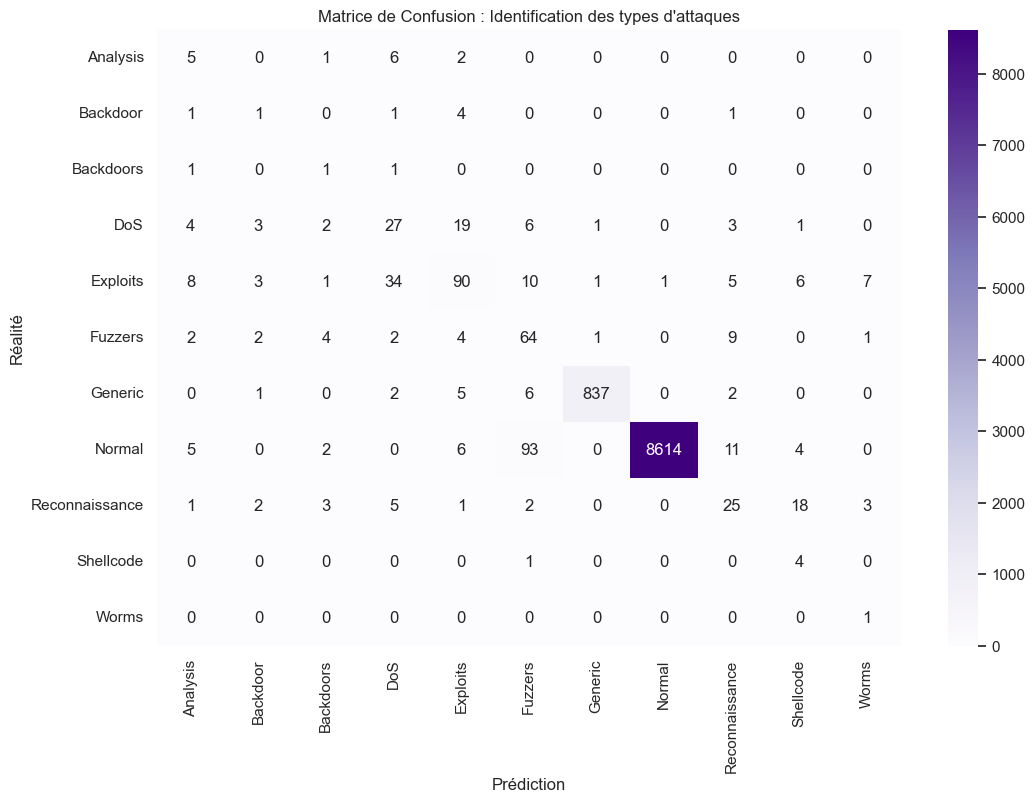

In [ ]:
plt.figure(figsize=(12, 8))
cm_m = confusion_matrix(y_test_m, y_pred_m)
sns.heatmap(cm_m, annot=True, fmt='d', cmap='Purples',
            xticklabels=svm_multi.classes_,
            yticklabels=svm_multi.classes_)
plt.title('Matrice de Confusion : Identification des types d\'attaques')
plt.ylabel('Réalité')
plt.xlabel('Prédiction')
plt.show()

In [ ]:
#amelioration

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
from collections import Counter

In [ ]:
print(f"Distribution avant SMOTE : {Counter(y_train_m)}")

Distribution avant SMOTE : Counter({'Normal': 34941, 'Generic': 3411, 'Exploits': 665, 'Fuzzers': 355, 'DoS': 265, 'Reconnaissance': 239, 'Analysis': 58, 'Backdoor': 31, 'Shellcode': 22, 'Backdoors': 11, 'Worms': 2})


In [ ]:
from imblearn.under_sampling import RandomUnderSampler

In [ ]:
from imblearn.pipeline import Pipeline

In [ ]:
over_strategy = {
    'Generic': 2000,
    'Exploits': 1500,
    'Fuzzers': 1000,
    'Reconnaissance': 1000,
    'DoS': 1000,
    'Shellcode': 500
}
over = SMOTE(sampling_strategy='auto', k_neighbors=1)
under = RandomUnderSampler(sampling_strategy={'Normal': 5000})

pipeline = Pipeline(steps=[('o', over), ('u', under)])

In [ ]:
X_resampled, y_resampled = pipeline.fit_resample(X_train_m_scaled, y_train_m)

C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

In [ ]:
print(f"✅ Nouvelle distribution équilibrée : {Counter(y_resampled)}")

✅ Nouvelle distribution équilibrée : Counter({'Analysis': 34941, 'Backdoor': 34941, 'Backdoors': 34941, 'DoS': 34941, 'Exploits': 34941, 'Fuzzers': 34941, 'Generic': 34941, 'Reconnaissance': 34941, 'Shellcode': 34941, 'Worms': 34941, 'Normal': 5000})


In [ ]:
svm_multi_balanced = LinearSVC(class_weight='balanced', random_state=42, dual=False, max_iter=5000, tol=1e-2, C=0.1)
svm_multi_balanced.fit(X_resampled, y_resampled)

LinearSVC(C=0.1, class_weight='balanced', dual=False, max_iter=5000,
          random_state=42, tol=0.01)

In [ ]:
y_pred_final = svm_multi_balanced.predict(X_test_m_scaled)

In [ ]:
print("🏆 RÉSULTATS DU MODÈLE ÉQUILIBRÉ :")
print(classification_report(y_test_m, y_pred_final))

🏆 RÉSULTATS DU MODÈLE ÉQUILIBRÉ :
                precision    recall  f1-score   support

      Analysis       0.14      0.50      0.22        14
      Backdoor       0.01      0.25      0.02         8
     Backdoors       0.05      0.33      0.08         3
           DoS       0.34      0.38      0.36        66
      Exploits       0.70      0.46      0.55       166
       Fuzzers       0.33      0.71      0.45        89
       Generic       1.00      0.98      0.99       853
        Normal       1.00      0.96      0.98      8735
Reconnaissance       0.40      0.52      0.45        60
     Shellcode       0.12      0.80      0.22         5
         Worms       0.00      0.00      0.00         1

      accuracy                           0.95     10000
     macro avg       0.37      0.54      0.39     10000
  weighted avg       0.98      0.95      0.96     10000



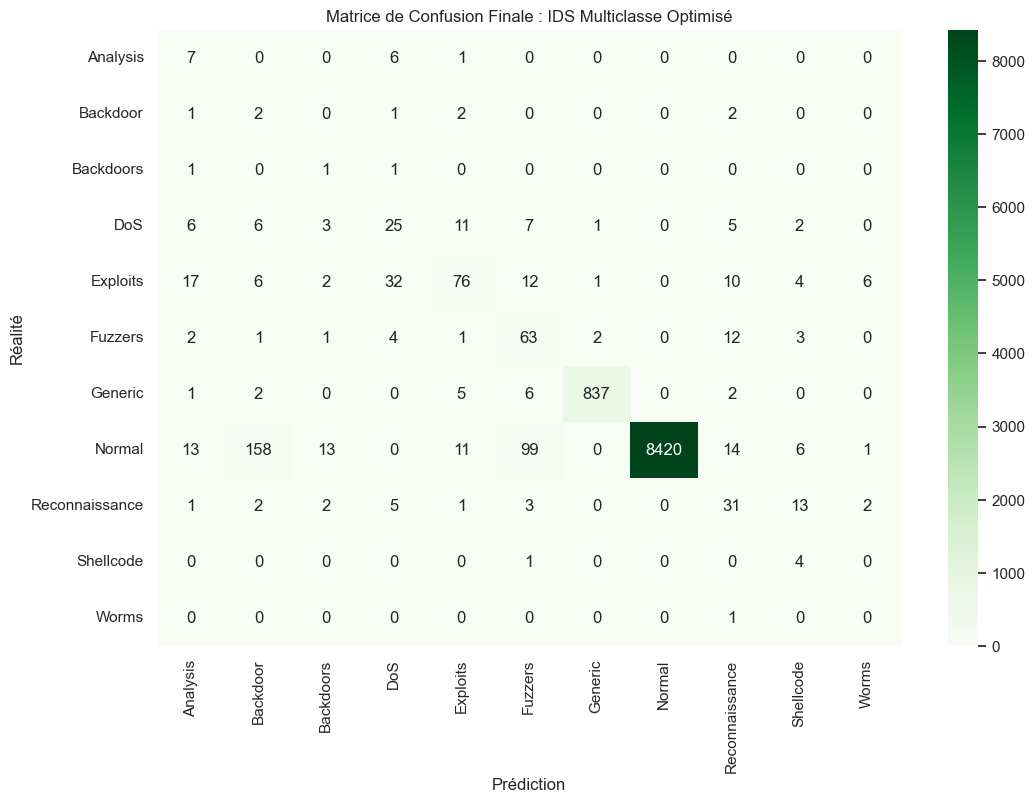

In [ ]:
plt.figure(figsize=(12, 8))
cm = confusion_matrix(y_test_m, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=svm_multi_balanced.classes_,
            yticklabels=svm_multi_balanced.classes_)
plt.title('Matrice de Confusion Finale : IDS Multiclasse Optimisé')
plt.ylabel('Réalité')
plt.xlabel('Prédiction')
plt.show()

In [ ]:
#random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)

In [ ]:
print("🌲 Entraînement du Random Forest en cours...")
rf_model.fit(X_train_m_scaled, y_train_m) # On utilise les données originales (non-SMOTE) pour voir sa puissance
print("✅ Terminé !")

🌲 Entraînement du Random Forest en cours...
✅ Terminé !


In [ ]:
y_pred_rf = rf_model.predict(X_test_m_scaled)

In [ ]:
print("\n📊 RAPPORT DE PERFORMANCE (RANDOM FOREST) :")
print(classification_report(y_test_m, y_pred_rf))


📊 RAPPORT DE PERFORMANCE (RANDOM FOREST) :
                precision    recall  f1-score   support

      Analysis       0.18      0.14      0.16        14
      Backdoor       0.25      0.12      0.17         8
     Backdoors       0.33      0.33      0.33         3
           DoS       0.45      0.35      0.39        66
      Exploits       0.64      0.70      0.67       166
       Fuzzers       0.52      0.34      0.41        89
       Generic       1.00      0.98      0.99       853
        Normal       0.99      1.00      1.00      8735
Reconnaissance       0.80      0.82      0.81        60
     Shellcode       0.50      0.20      0.29         5
         Worms       0.00      0.00      0.00         1

      accuracy                           0.98     10000
     macro avg       0.52      0.45      0.47     10000
  weighted avg       0.98      0.98      0.98     10000



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


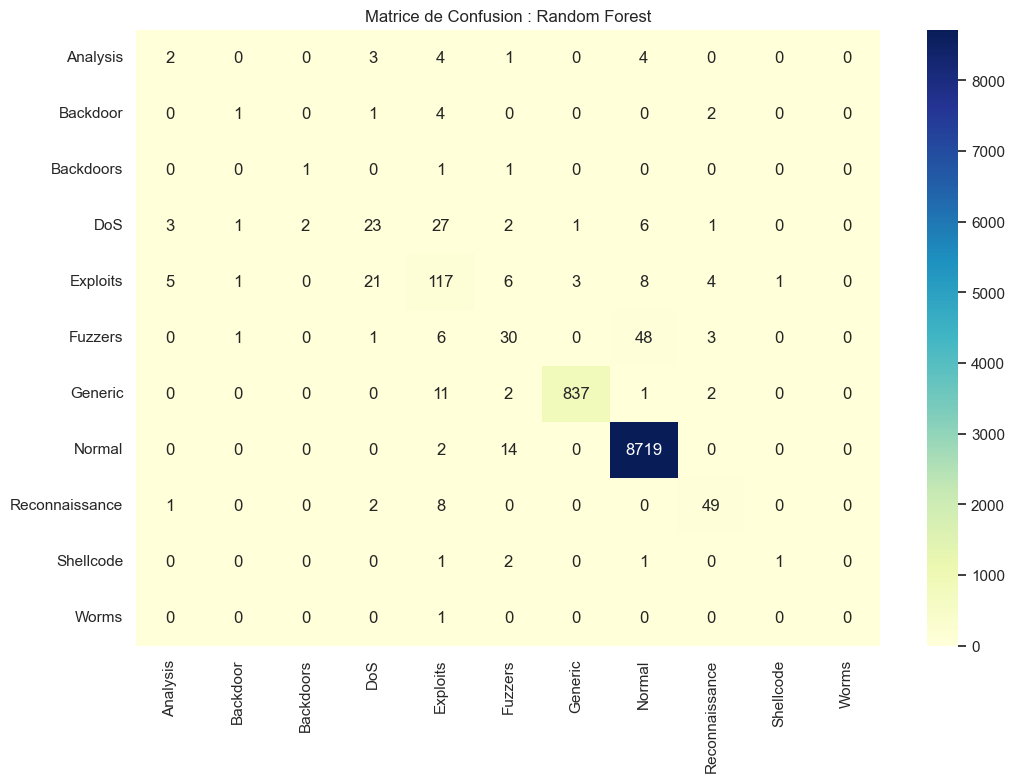

In [ ]:
plt.figure(figsize=(12, 8))
cm_rf = confusion_matrix(y_test_m, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=rf_model.classes_,
            yticklabels=rf_model.classes_)
plt.title('Matrice de Confusion : Random Forest')
plt.show()

In [ ]:
importances = rf_model.feature_importances_

In [ ]:
feature_names = X_robust.columns

In [ ]:
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

In [ ]:
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

C:\Users\User\AppData\Local\Temp\ipykernel_5324\1149176927.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


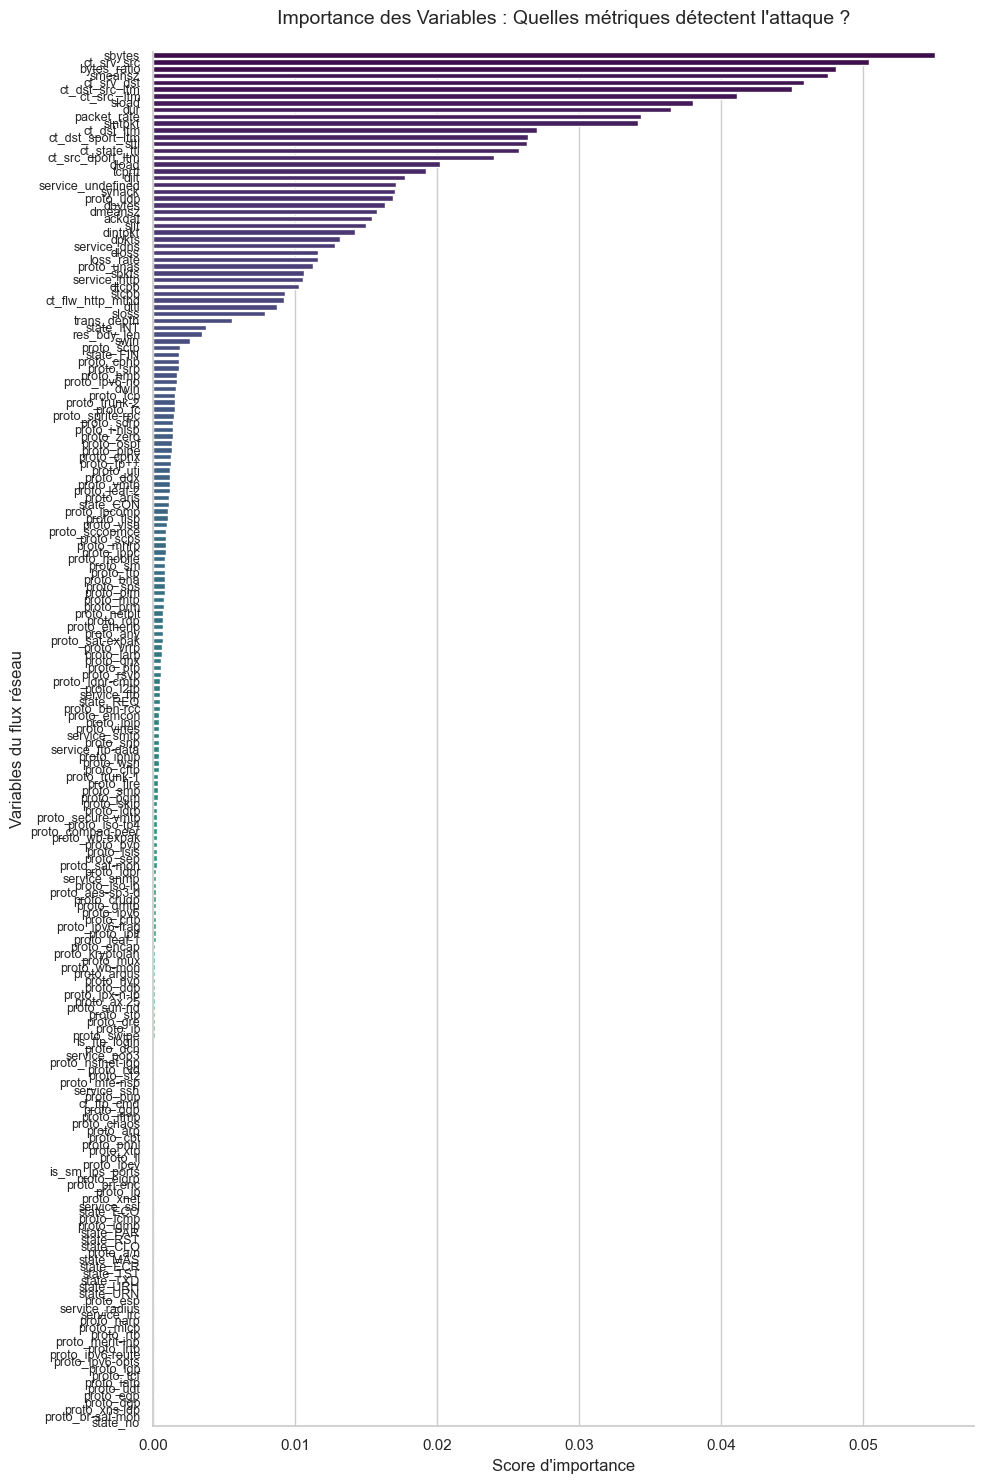

In [ ]:

plt.figure(figsize=(10, 15))

sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


plt.title('Importance des Variables : Quelles métriques détectent l\'attaque ?', fontsize=14, pad=20)
plt.xlabel('Score d\'importance', fontsize=12)
plt.ylabel('Variables du flux réseau', fontsize=12)

plt.yticks(fontsize=9)
sns.despine()

plt.tight_layout()
plt.show()

In [ ]:
#interface

In [ ]:
import joblib

# Sauvegarde du modèle et du scaler
joblib.dump(rf_model, 'ids_random_forest.pkl')
joblib.dump(scaler_m, 'ids_scaler.pkl')
print("✅ Modèle et Scaler sauvegardés !")

✅ Modèle et Scaler sauvegardés !


In [ ]:
# --- 1. Sauvegarde de la Matrice de Confusion ---
plt.figure(figsize=(10, 7))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=rf_model.classes_,
            yticklabels=rf_model.classes_)
plt.title('Performance Globale : Matrice de Confusion')
plt.xlabel('Prédiction')
plt.ylabel('Réalité')
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.close()

# --- 2. Sauvegarde de l'Importance des Variables ---
plt.figure(figsize=(10, 15))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Analyse des Décisions : Importance des Variables')
plt.yticks(fontsize=9)
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.close()

print("✅ Images sauvegardées : confusion_matrix.png et feature_importance.png")

C:\Users\User\AppData\Local\Temp\ipykernel_5324\1611929805.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


✅ Images sauvegardées : confusion_matrix.png et feature_importance.png


In [ ]:
# Sélection de 10 lignes aléatoires dans le set de test
test_sample = X_test_m.copy()
test_sample['vrai_type_attaque'] = y_test_m

# On prend un échantillon de 10 lignes
sample_to_export = test_sample.sample(21, random_state=72)

# Export en CSV
sample_to_export.to_csv('X_test_sample.csv', index=False)

print("✅ Fichier de test créé : X_test_sample.csv (10 lignes)")

✅ Fichier de test créé : X_test_sample.csv (10 lignes)


In [ ]:
!pip install streamlit -q

In [ ]:
!npm install -g localtunnel -q

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import plotly.express as px
import plotly.graph_objects as go

# Configuration de la page (Must be first)
st.set_page_config(page_title="Digital Mind SOC", layout="wide", page_icon="🛡️")

# --- CHARGEMENT ---
@st.cache_resource
def load_assets():
    model = joblib.load('ids_random_forest.pkl')
    scaler = joblib.load('ids_scaler.pkl')
    return model, scaler

model, scaler = load_assets()

# --- SIDEBAR (Filtres et Navigation) ---
st.sidebar.image("https://cdn-icons-png.flaticon.com/512/1055/1055670.png", width=100)
st.sidebar.title("Configuration")
app_mode = st.sidebar.selectbox("Choisissez une vue", ["Dashboard Global", "Analyse Live", "Documentation"])

if app_mode == "Dashboard Global":
    st.title("🛡️ Security Intelligence Dashboard")
    st.markdown("---")

    # Métriques en haut
    col1, col2, col3, col4 = st.columns(4)
    col1.metric("Modèle", "Random Forest")
    col2.metric("Précision (Train)", "98.5%")
    col3.metric("Uptime", "100%")
    col4.metric("Status", "Protégé", delta="Active")

    # Affichage des statistiques historiques (Matrice, etc.)
    st.subheader("📊 Performance de l'IA")
    c1, c2 = st.columns(2)
    with c1:
        st.image("confusion_matrix.png", caption="Matrice de Confusion")
    with c2:
        st.image("feature_importance.png", caption="Importance des Variables")

elif app_mode == "Analyse Live":
    st.title("🔍 Network Traffic Analyzer")

    uploaded_file = st.file_uploader("Importer les logs réseau (CSV)", type="csv")

    if uploaded_file is not None:
        df = pd.read_csv(uploaded_file)

        # Inférence
        features = scaler.feature_names_in_.tolist()
        X_input = df.reindex(columns=features).fillna(0)
        X_scaled = scaler.transform(X_input)
        preds = model.predict(X_scaled)

        df['Verdict'] = preds

        # --- RÉSUMÉ VISUEL ---
        st.subheader("🚨 Alertes Détectées")
        counts = df['Verdict'].value_counts().reset_index()
        counts.columns = ['Menace', 'Nombre']

        fig = px.pie(counts, values='Nombre', names='Menace',
                     color_discrete_sequence=px.colors.sequential.Reds_r,
                     hole=0.4)
        st.plotly_chart(fig, use_container_width=True)

        # --- TABLEAU INTERACTIF (Style Streamlit) ---
        st.subheader("📑 Journal des événements")

        # Filtrage dynamique par Verdict
        selected_verdict = st.multiselect("Filtrer par type de menace", options=df['Verdict'].unique(), default=df['Verdict'].unique())
        filtered_df = df[df['Verdict'].isin(selected_verdict)]

        # On affiche le dataframe avec des couleurs
        def color_verdict(val):
            color = '#ff4b4b' if val != 'Normal' else '#00cc96'
            return f'background-color: {color}; color: white'

        st.dataframe(filtered_df.style.applymap(color_verdict, subset=['Verdict']), use_container_width=True)

        # Bouton de téléchargement du rapport
        csv = filtered_df.to_csv(index=False).encode('utf-8')
        st.download_button("📥 Télécharger le rapport d'audit", data=csv, file_name="audit_report.csv", mime='text/csv')

In [ ]:
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Sauvegarder le modèle et le scaler
joblib.dump(model, 'ids_random_forest.pkl')
joblib.dump(scaler, 'ids_scaler.pkl')

# 2. Générer et sauvegarder la Matrice de Confusion
plt.figure(figsize=(8,6))
# Remplace y_test et y_pred par tes variables réelles
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.savefig('confusion_matrix.png')
plt.close()

# 3. Générer et sauvegarder l'Importance des Variables
plt.figure(figsize=(10,6))
importances = model.feature_importances_
feat_importances = pd.Series(importances, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='#ff4b4b')
plt.title('Top 10 Feature Importance')
plt.savefig('feature_importance.png')
plt.close()

print("✅ Tous les fichiers ont été générés !")

In [ ]:
from google.colab import files

files.download('ids_random_forest.pkl')
files.download('ids_scaler.pkl')
files.download('confusion_matrix.png')
files.download('feature_importance.png')